# 3. Gravity: Sub-Regions of the Force Field

The [hydro sub-region page](03_hydro_Get_Subregions.md) built a mass budget:
regions carve the grid, boundary cells are split by volume fraction, and the
pieces add up. This page applies the *same* region machinery to the gravity
data — and the interesting part is what changes when the cells carry no mass.

A gravity cell holds a field: the potential `:epot` and the acceleration
components `:ax`, `:ay`, `:az`. There is nothing to sum. `msum` is not defined
for a `GravDataType`, and asking `getvar` for `:mass` returns an error rather
than a number. What a region gives you here is a **volume**, and with it the
right weights for averaging a field over that volume.

That turns out to be enough to weigh the galaxy anyway — not by counting its
mass, but by asking the force field how much mass it is responding to. The two
answers disagree by a factor of about three and a half, and the disagreement
is the point.

**Reading convention.** Longer code cells are cut in two by a banner line:

```
# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
```

Everything above the banner is the Mera part. Everything below it is Makie
decoration — read it if you want the plot, skim it otherwise.

**On this page**

1. the field, and what it cannot weigh
2. one sphere, three volumes
3. averaging a field over a region
4. two different `center`s — a trap worth naming
5. shells: the rotation curve the force field implies
6. weighing the galaxy: Gauss's law vs the mass ledger
7. a second opinion: the gas rotation
8. composites and the `@region` block
9. the cut you measure is the cut you see
10. reference: the classic symbol API
11. practical guidance


## 1. The Field, and What It Cannot Weigh

Three data types from one output, all loaded at the same resolution so the
comparisons later are like for like: the gravity field, the gas, and the star
particles. `lmax=10` is a deliberate choice — the potential is smooth on
scales far larger than the finest cells, so nothing in this page needs the
deepest levels, and the page stays runnable on a laptop.


In [1]:
using Mera, CairoMakie
# Makie also exports geometric names (Sphere, Cylinder, ...) — state explicitly
# that we mean Mera's region types:
import Mera: Sphere, Cuboid, Cylinder, SphericalShell, CylindricalShell
CairoMakie.activate!()

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/manu_sim_sf_L14"
info = getinfo(400, path, verbose=false)

grav  = getgravity(info, lmax=10, verbose=false, show_progress=false)
gas   = gethydro(info, [:rho, :vx, :vy, :vz], lmax=10, smallr=1e-11,
                 verbose=false, show_progress=false)
stars = getparticles(info, verbose=false, show_progress=false)

kpc = info.scale.kpc          # code length -> kpc

println("gravity cells  : ", length(grav.data), "   columns: ", keys(grav.data[1]))
println("gas cells      : ", length(gas.data))
println("star particles : ", length(stars.data))
println("box            : ", round(grav.boxlen * kpc, sigdigits=4),
        " kpc, centre [:bc] at (24, 24, 24) kpc")


[ Info: Precompiling Mera [02f895e8-fdb1-4346-8fe6-c721699f5126] (cache misses: include_dependency fsize change (4), dep missing source (6), mismatched flags (10))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



[ Info: Precompiling MeraMakieExt [defab1b5-6ec5-5409-a2f4-69ec619b2a0e] (cache misses: wrong dep version loaded (10))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


[ Info: Mera v1.8.0


gravity cells  : 4879946

   columns: (:level, :cx, :cy, :cz, :epot, :ax, :ay, :az)
gas cells      : 4879946
star particles : 508939
box            : 48.0 kpc, centre [:bc] at (24, 24, 24) kpc


`:cx, :cy, :cz, :level` are the cell's address on the AMR lattice; `:epot` and
`:ax, :ay, :az` are the field it carries. No density, no mass — so the two
calls below are errors, not zeros:

```julia
msum(subregion(grav, Sphere(10.)), :Msol)     # MethodError — no method for GravDataType
getvar(subregion(grav, Sphere(10.)), :mass)   # "Variable :mass not found in gravity data"
```

The second message suggests the way out: `getvar` accepts a `hydro_data=`
keyword, so gravity and hydro quantities can be requested from one object when
the two cover the same cells. On this page we keep the datasets separate and
let the *region* be what they share — the same `Sphere` value applied to gas,
to stars, and to the field.

First, what the field looks like. `projection` has a two-object form,
`projection(hydro, gravity, var)`: the hydro object supplies the weights, the
gravity object the field. So a force map is a mass-weighted average of |a|
along the line of sight.


In [2]:
# ─────────────────────────────────────────────────────────────────────
# FIGURE INFRASTRUCTURE for the whole page — skim freely on first read.
# The one Mera-relevant definition is `aproj` at the bottom: the projection
# defaults every force map reuses.
# ─────────────────────────────────────────────────────────────────────
const ALIM = (-8.6, -6.2)   # log10 |a| [cm/s²] — one colour scale for every force map

function show_a!(ax, p; decorate=false)
    m  = p.maps[:a_magnitude]
    xs = range(p.cextent[1]*kpc, p.cextent[2]*kpc; length=size(m, 1))
    ys = range(p.cextent[3]*kpc, p.cextent[4]*kpc; length=size(m, 2))
    heatmap!(ax, xs, ys, log10.(max.(m, 1e-12)); colormap=:magma, colorrange=ALIM)
    ax.aspect = DataAspect()
    ax.backgroundcolor = :black
    decorate || hidedecorations!(ax)
    return ax
end

a_bar!(pos) = Colorbar(pos; colormap=:magma, colorrange=ALIM,
                       label="log₁₀ |a|  [cm s⁻²]")

function scalebar!(ax, x0, y0, len)
    lines!(ax, [x0, x0 + len], [y0, y0]; color=:white, linewidth=3)
    text!(ax, x0 + len/2, y0 + 0.6; text="$(round(Int, len)) kpc", color=:white,
          fontsize=10, align=(:center, :bottom))
end

# mass-weighted projection of a GRAVITY field: hydro gives the weights,
# gravity gives the field
aproj(h, g; kwargs...) = projection(h, g, :a_magnitude, :cm_s2; direction=:z,
                                    center=[:bc], pxsize=[0.2, :kpc],
                                    verbose=false, show_progress=false, kwargs...)


aproj (generic function with 1 method)

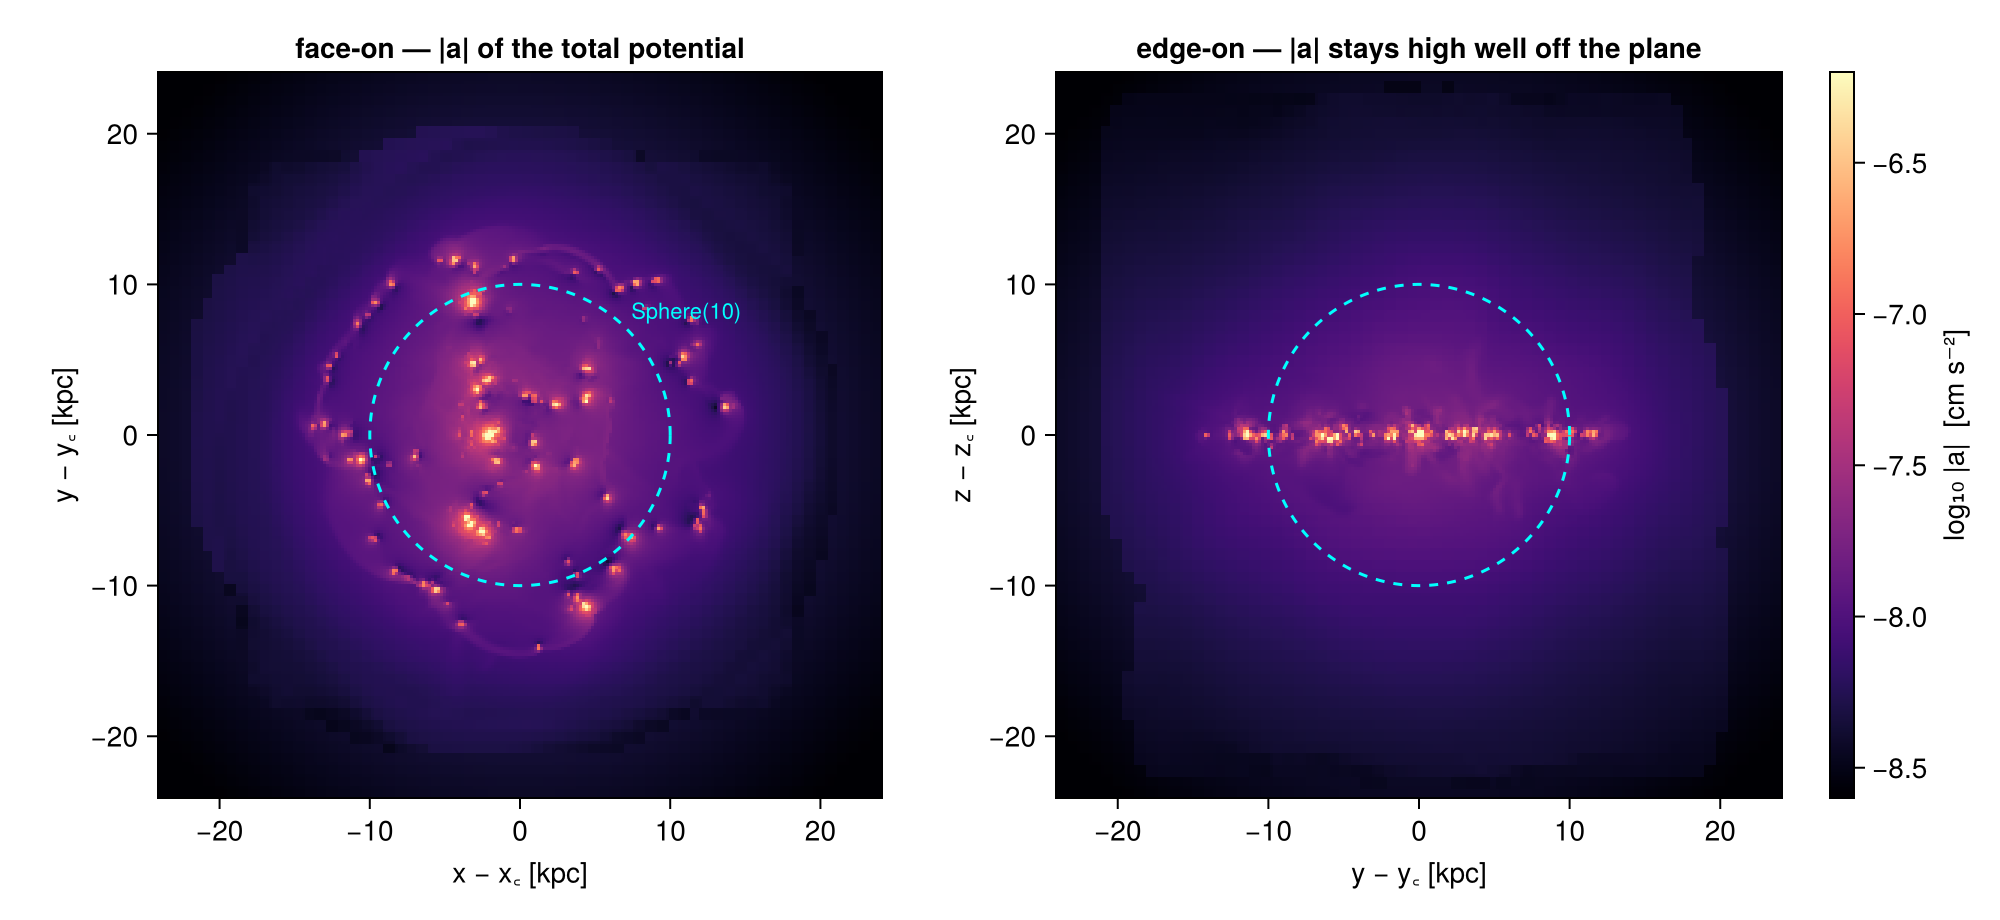

In [3]:
pa_face = aproj(gas, grav)                  # face-on
pa_edge = aproj(gas, grav; direction=:x)    # edge-on


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1000, 460))
axf = Axis(fig[1, 1], title="face-on — |a| of the total potential",
           xlabel="x − x꜀ [kpc]", ylabel="y − y꜀ [kpc]")
show_a!(axf, pa_face; decorate=true)
arc!(axf, Point2f(0, 0), 10., 0, 2π; color=:cyan, linewidth=1.5, linestyle=:dash)
text!(axf, 7.4, 7.4; text="Sphere(10)", color=:cyan, fontsize=11)

axe = Axis(fig[1, 2], title="edge-on — |a| stays high well off the plane",
           xlabel="y − y꜀ [kpc]", ylabel="z − z꜀ [kpc]")
show_a!(axe, pa_edge; decorate=true)
arc!(axe, Point2f(0, 0), 10., 0, 2π; color=:cyan, linewidth=1.5, linestyle=:dash)
a_bar!(fig[1, 3])
fig


The gas lives in a thin disc; the acceleration it feels does not fall away
nearly as quickly off the plane. Read that panel carefully rather than
literally — it is a *mass-weighted* average along the line of sight, so it
shows the field where there is gas to weight it, not the field everywhere. It
is a hint, not a measurement. §6 turns the hint into a number.


## 2. One Sphere, Three Volumes

The hydro page measured one sphere three ways and got three masses. Here the
same three boundary treatments give three *volumes*, and this time there is an
exact answer to check against: a sphere of radius $R$ has volume
$\tfrac{4}{3}\pi R^3$, no simulation required.

- **whole cells** — keep every cell the sphere touches (the classic symbol API
  with its default `cell=true`): a strict superset, hence a strict upper bound;
- **centre test** — keep cells whose centre lies inside (`split=false`): a
  subset of the first, close to the truth but with no guaranteed sign;
- **split** — keep boundary cells with a `:fraction` column recording how much
  of each lies inside; `getvar(:volume)` multiplies by it.


In [4]:
R  = 10.0
sph = Sphere(R)                       # center=[:bc], range_unit=:kpc are the defaults

g_split = subregion(grav, sph, verbose=false)                 # split=true (default)
g_centre = subregion(grav, sph, split=false, verbose=false)   # centre-inside test
g_whole = subregion(grav, :sphere; radius=R, center=[:bc], range_unit=:kpc,
                    verbose=false)                            # classic API, cell=true

V_exact = 4/3 * π * R^3
V = Dict{String,Float64}()
for (name, obj) in [("whole cells (classic API)", g_whole),
                    ("centre test  (split=false)", g_centre),
                    ("split        (split=true)", g_split)]
    V[name] = sum(getvar(obj, :volume, :kpc3))
    println(rpad(name, 28), rpad(length(obj.data), 10),
            rpad(round(V[name], sigdigits=8), 14),
            "dev = ", round(100*(V[name]/V_exact - 1), sigdigits=3), " %")
end
println(rpad("analytic 4/3 π R³", 28), rpad("", 10), round(V_exact, sigdigits=8))

# where does the whole-cell excess come from? look at the partially-filled cells
fr   = Mera.select(g_split.data, :fraction)
cs   = getvar(g_split, :cellsize, :kpc)
edge = 0 .< fr .< 1
println()
println("partial cells (0 < fraction < 1) : ", count(edge), "  =  ",
        round(100*count(edge)/length(fr), digits=2), " % of the selected rows")
println("their mean size, per cell        : ", round(sum(cs[edge])/count(edge), digits=3), " kpc")
println("             ... per unit volume : ",
        round(sum(cs[edge].^4)/sum(cs[edge].^3), digits=3), " kpc  ← the coarse ones dominate")
println("volume they would add if counted whole : ",
        round(sum((1 .- fr[edge]) .* cs[edge].^3), sigdigits=4), " kpc³")
println("measured whole-cell excess            : ",
        round(V["whole cells (classic API)"] - V["split        (split=true)"], sigdigits=4), " kpc³")


whole cells (classic API)   2506705   

4692.9682     dev = 12.0 %
centre test  (split=false)  

2488588   4196.3146     dev = 0.18 %
split        (split=true)   2504682   

4188.7277     dev = -0.00149 %
analytic 4/3 π R³                     4188.7902



partial cells (0 < fraction < 1) : 31813  =  1.27 % of the selected rows
their mean size, per cell        : 0.155 kpc
             ... per unit volume : 0.644 kpc  ← the coarse ones dominate
volume they would add if counted whole : 471.8 kpc³
measured whole-cell excess            : 504.2 kpc³


The split volume lands on the analytic sphere to about one part in $10^5$ —
the residual is the sub-sampling of curved boundary cells (`nsub`, 8 per axis
by default), not a systematic. The centre test happens to land close here, at
two parts in a thousand, but carries no promise that it will next time.

The whole-cell number deserves a second look: **twelve percent** too much
volume, contributed by cells that are barely one percent of the selection.
The diagnostic underneath explains how so few cells carry so much — and it is
a distinctly AMR effect. Count the partially-filled cells one by one and their
mean size is 0.155 kpc; weight them by the volume they actually carry and it
quadruples, to 0.644 kpc — essentially the coarsest level in the run. A sphere
of radius 10 kpc has its boundary *outside* the refined disc, and one coarse
cell holds some seventy times the volume of a cell two levels finer, so a
minority of large cells at the rim outweighs all the small ones along the rest
of the boundary. Counting those partial cells whole accounts for 472 of the
504 kpc³ excess; the remainder is the handful of extra cells the classic test
keeps and the value-type test does not.

The lesson generalises: the error of a whole-cell cut is a property of the
grid *where the boundary happens to fall*, not of the region's size. The same
sphere centred somewhere fully refined would over-count far less.

Nothing about any of this is hydro-specific: it is the same `:fraction`
column, and `getvar(:volume)` on gravity data is fraction-aware exactly as
`getvar(:mass)` is on hydro data.


## 3. Averaging a Field Over a Region

With no mass to sum, the natural question about a region becomes *what is the
average field inside it* — and on an AMR grid, that question has a wrong
answer that is very easy to write:

```julia
sum(epot) / length(epot)      # ← the mean over CELLS, not over VOLUME
```

A refined cell is not a smaller share of the region; it is a smaller *volume*.
Averaging over cells silently reweights the region toward wherever the grid is
refined — which, in a galaxy simulation, is exactly where the interesting
physics distorted the answer. The volume-weighted mean is the honest one, and
the `:fraction` column makes it correct at the boundary too.


In [5]:
ep  = getvar(g_split, :epot, :km2_s2)     # specific potential, in (km/s)²
vol = getvar(g_split, :volume)            # fraction-aware weights

ep_c = getvar(g_centre, :epot, :km2_s2)
vol_c = getvar(g_centre, :volume)

println("mean over cells,  split region   : ", round(sum(ep)/length(ep), sigdigits=6), " (km/s)²")
println("mean over volume, centre test    : ", round(sum(ep_c .* vol_c)/sum(vol_c), sigdigits=6), " (km/s)²")
println("mean over volume, split region   : ", round(sum(ep .* vol)/sum(vol), sigdigits=6), " (km/s)²")
println()
println("cell mean vs volume mean         : ",
        round(100*((sum(ep)/length(ep)) / (sum(ep .* vol)/sum(vol)) - 1), sigdigits=3), " %")
println("centre test vs split, volume mean: ",
        round(100*((sum(ep_c .* vol_c)/sum(vol_c)) / (sum(ep .* vol)/sum(vol)) - 1), sigdigits=3), " %")


mean over cells,  split region   : -1907.2

 (km/s)²
mean over volume, centre test    : -1632.52 (km/s)²
mean over volume, split region   : -1632.64 (km/s)²

cell mean vs volume mean         : 16.8 %
centre test vs split, volume mean: -0.00738 %


Two errors of very different size, and it is worth being clear about which one
matters. Ignoring the volume weight moves the answer by about **seventeen
percent**: the refined cells cluster in the deep centre of the potential, and
counting them equally drags the mean down with them. Ignoring the boundary
*fractions* moves it by parts in $10^5$: a shell of half-counted cells at $r = 10$
kpc is a small fraction of a sphere's volume, and the field varies slowly
across it.

That ordering is the practical rule for field data: **weight by volume always,
split the boundary when the boundary is where the signal is** — a thin shell,
a narrow slab, a region only a few cells across.


## 4. Two Different `center`s — a Trap Worth Naming

Derived gravity quantities like `:ar_sphere` (the radial component of the
acceleration) are not stored in the file; `getvar` computes them from
`:ax, :ay, :az` and the cell position *relative to an origin*. That origin is
`getvar`'s own `center` keyword — and it is a different argument from the
`center` that positioned the region.

Both default, and they default differently:

| keyword | belongs to | default |
|:--|:--|:--|
| `center` in `Sphere(10.; center=[:bc])` | the **region** — where the shape sits | `[:bc]`, the box centre |
| `center` in `getvar(obj, :ar_sphere, center=[:bc])` | the **coordinate origin** for derived quantities | `[0., 0., 0.]`, the box **corner** |

Leaving the second one out does not raise an error — the corner is a
perfectly well-defined origin, so the call succeeds and hands back a plausible
number. Mera does now say something about it: the first time a frame-relative
quantity is computed about the corner in a session it prints a one-off
reminder naming that quantity. The cell below triggers it. Treat it as a
nudge, not a guard: nothing is blocked, the default has not changed, and
`verbose(false)` silences it along with every other Mera message.


In [6]:
w = getvar(g_split, :volume)     # volume weights, used for every mean below

ar_corner = getvar(g_split, :ar_sphere, :cm_s2)                  # origin = box corner (default!)
ar_galaxy = getvar(g_split, :ar_sphere, :cm_s2, center=[:bc])    # origin = galaxy centre

println("⟨a_r⟩ about the box corner  : ", round(sum(ar_corner .* w)/sum(w), sigdigits=4), " cm/s²")
println("⟨a_r⟩ about the box centre  : ", round(sum(ar_galaxy .* w)/sum(w), sigdigits=4), " cm/s²")
println("ratio                       : ",
        round((sum(ar_corner .* w)/sum(w)) / (sum(ar_galaxy .* w)/sum(w)), sigdigits=3))


[Mera] Hint: getvar(:ar_sphere) has no `center` — it is measured about the box CORNER.


             Pass center=[:bc] for the box centre, or center=[x, y, z] with center_unit.
             This is a different argument from the `center` that places a region; give it
             the same origin. Absolute positions :x/:y/:z are unaffected.
             (shown once per session; verbose(false) silences Mera's messages)
⟨a_r⟩ about the box corner  : -1.99e-9

 cm/s²
⟨a_r⟩ about the box centre  : -1.526e-8 cm/s²
ratio                       : 0.13


Nearly an order of magnitude apart, and both numbers are real measurements —
of different things. Whenever a quantity's *name* contains a geometry —
`:ar_sphere`, `:ar_cylinder`, `:aϕ_sphere`, `:r_cylinder`, `:vϕ_cylinder` —
pass `center` explicitly, and pass the same one you gave the region. Absolute
positions (`:x`, `:y`, `:z`) are the exception: for those the box corner *is*
the right default, because it returns the simulation's own coordinates.


## 5. Shells: the Rotation Curve the Force Field Implies

A `SphericalShell` is a region like any other, so a radial profile is a stack
of them. For each shell we take the volume-weighted mean of $a_r$ and turn it
into the speed a test particle would need to stay on a circular orbit there,

$$v_\mathrm{c}(r) = \sqrt{|a_r|\, r}\,,$$

which is a statement about the *potential* — it does not care whether the mass
producing it is gas, stars, or something the output never wrote down.

The loop below computes both variants from the same shells: the correct one,
and the one with `getvar`'s `center` left at its default. The cost of one
forgotten keyword is easier to see as a curve than as a number.


v_c at 8 kpc, origin = galaxy centre : 189.1

 km/s
v_c at 8 kpc, origin = box corner    : 65.8 km/s


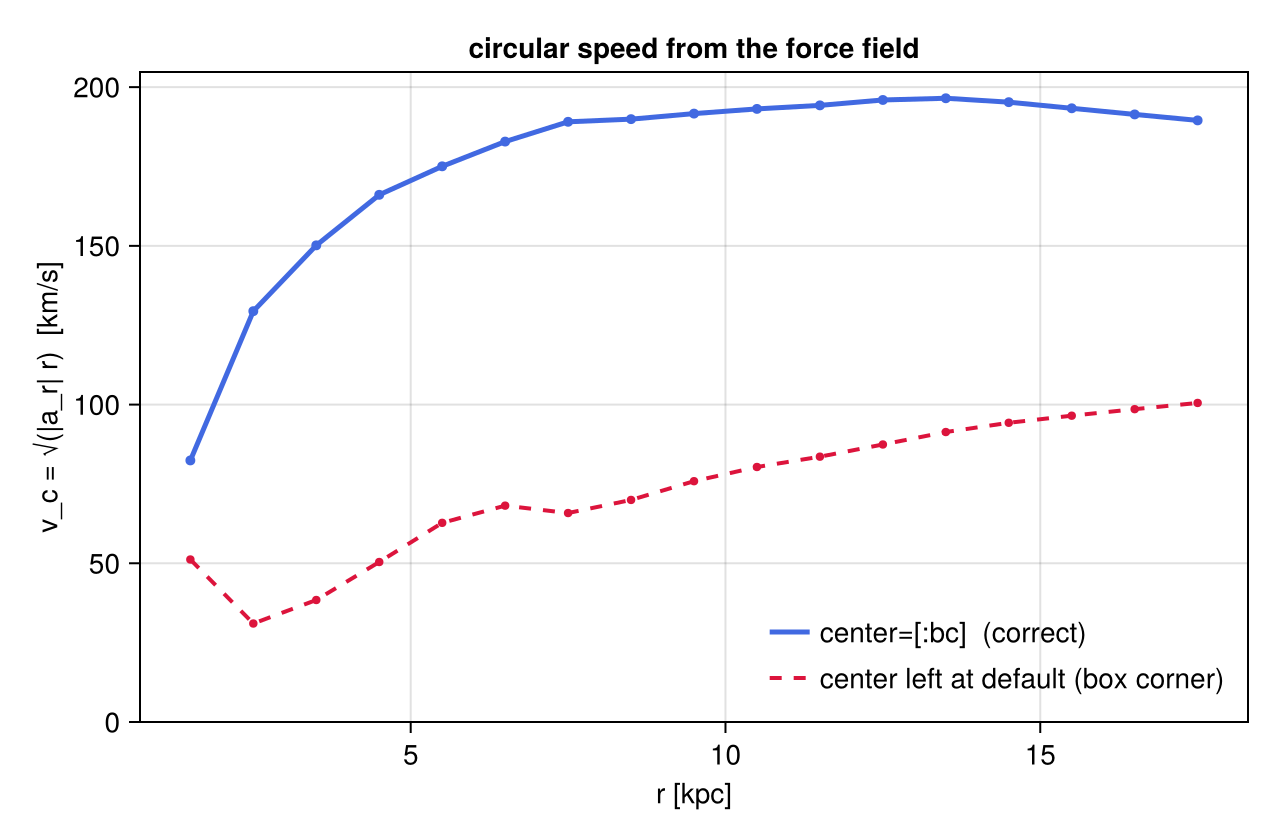

In [7]:
const KPC  = 3.085677581e21      # cm
const GCGS = 6.67430e-8          # cm³ g⁻¹ s⁻²
const MSOL = 1.98892e33          # g

radii = collect(1.5:1.0:17.5)
vc_galaxy = Float64[]
vc_corner = Float64[]
for r in radii
    sh = subregion(grav, SphericalShell(r - 0.5, r + 0.5), verbose=false)
    ws = getvar(sh, :volume)
    ag = sum(getvar(sh, :ar_sphere, :cm_s2, center=[:bc]) .* ws) / sum(ws)
    ac = sum(getvar(sh, :ar_sphere, :cm_s2)              .* ws) / sum(ws)
    push!(vc_galaxy, sqrt(abs(ag) * r * KPC) / 1e5)     # km/s
    push!(vc_corner, sqrt(abs(ac) * r * KPC) / 1e5)
end
println("v_c at 8 kpc, origin = galaxy centre : ",
        round(vc_galaxy[findfirst(==(7.5), radii)], digits=1), " km/s")
println("v_c at 8 kpc, origin = box corner    : ",
        round(vc_corner[findfirst(==(7.5), radii)], digits=1), " km/s")


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(640, 420))
ax  = Axis(fig[1, 1], xlabel="r [kpc]", ylabel="v_c = √(|a_r| r)  [km/s]",
           title="circular speed from the force field")
lines!(ax, radii, vc_galaxy; color=:royalblue, linewidth=2.5, label="center=[:bc]  (correct)")
scatter!(ax, radii, vc_galaxy; color=:royalblue, markersize=7)
lines!(ax, radii, vc_corner; color=:crimson, linewidth=2, linestyle=:dash,
       label="center left at default (box corner)")
scatter!(ax, radii, vc_corner; color=:crimson, markersize=6)
axislegend(ax; position=:rb, framevisible=false)
ylims!(ax, 0, nothing)
fig


The blue curve rises through the inner few kpc and then flattens near 190 km/s
— a textbook galactic rotation curve, obtained without touching a single mass.
The red curve is the same shells with the origin at the box corner: it is not
noise, it is a perfectly well-defined measurement of the wrong thing, and
nothing but the physics tells you so.


## 6. Weighing the Galaxy: Gauss's Law vs the Mass Ledger

Now the payoff, and the reason this page loads three datasets.

For a roughly spherical potential, the radial acceleration on a shell measures
all the mass inside it — Gauss's law, in the form

$$M_\mathrm{dyn}(<r) \;=\; \frac{|a_r|\, r^2}{G}\,.$$

That is one number. The other comes from the hydro page's machinery: apply the
*same* `Sphere(r)` to the gas and to the star particles and sum what is
actually there. Same region value, three data types, two independent answers
to "how much mass is inside this sphere".


In [8]:
rows = NamedTuple[]
for r in [2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0]
    sph_r = Sphere(r)                                   # ONE region value ...

    sh   = subregion(grav, SphericalShell(r - 0.25, r + 0.25), verbose=false)
    ws   = getvar(sh, :volume)
    ar   = sum(getvar(sh, :ar_sphere, :cm_s2, center=[:bc]) .* ws) / sum(ws)
    Mdyn = abs(ar) * (r*KPC)^2 / GCGS / MSOL            # ... asked of the field,

    Mgas  = msum(subregion(gas,   sph_r, verbose=false), :Msol)   # ... of the gas,
    Mstar = msum(subregion(stars, sph_r, verbose=false), :Msol)   # ... and of the stars

    push!(rows, (r=r, Mdyn=Mdyn, Mgas=Mgas, Mstar=Mstar))
end

println(rpad("r [kpc]", 9), rpad("M_dyn", 12), rpad("M_gas", 12), rpad("M_star", 12),
        rpad("M_baryon", 12), "M_dyn / M_baryon")
println("-"^73)
for t in rows
    Mb = t.Mgas + t.Mstar
    println(rpad(t.r, 9), rpad(round(t.Mdyn, sigdigits=4), 12),
            rpad(round(t.Mgas, sigdigits=4), 12), rpad(round(t.Mstar, sigdigits=4), 12),
            rpad(round(Mb, sigdigits=4), 12), round(t.Mdyn/Mb, digits=2))
end


r [kpc]  M_dyn       

M_gas       M_star      M_baryon    M_dyn / M_baryon
-------------------------------------------------------------------------
2.0      5.411e9     1.858e9     4.984e8     2.356e9     2.3
4.0      2.328e10    5.918e9     1.853e9     7.77e9      3.0
6.0      4.453e10    9.955e9     3.054e9     1.301e10    3.42
8.0      6.694e10    1.486e10    4.148e9     1.901e10    3.52
10.0     8.636e10    1.821e10    4.785e9     2.3e10      3.76
12.0     1.063e11    2.329e10    5.27e9      2.856e10    3.72
16.0     1.377e11    2.946e10    5.754e9     3.521e10    3.91


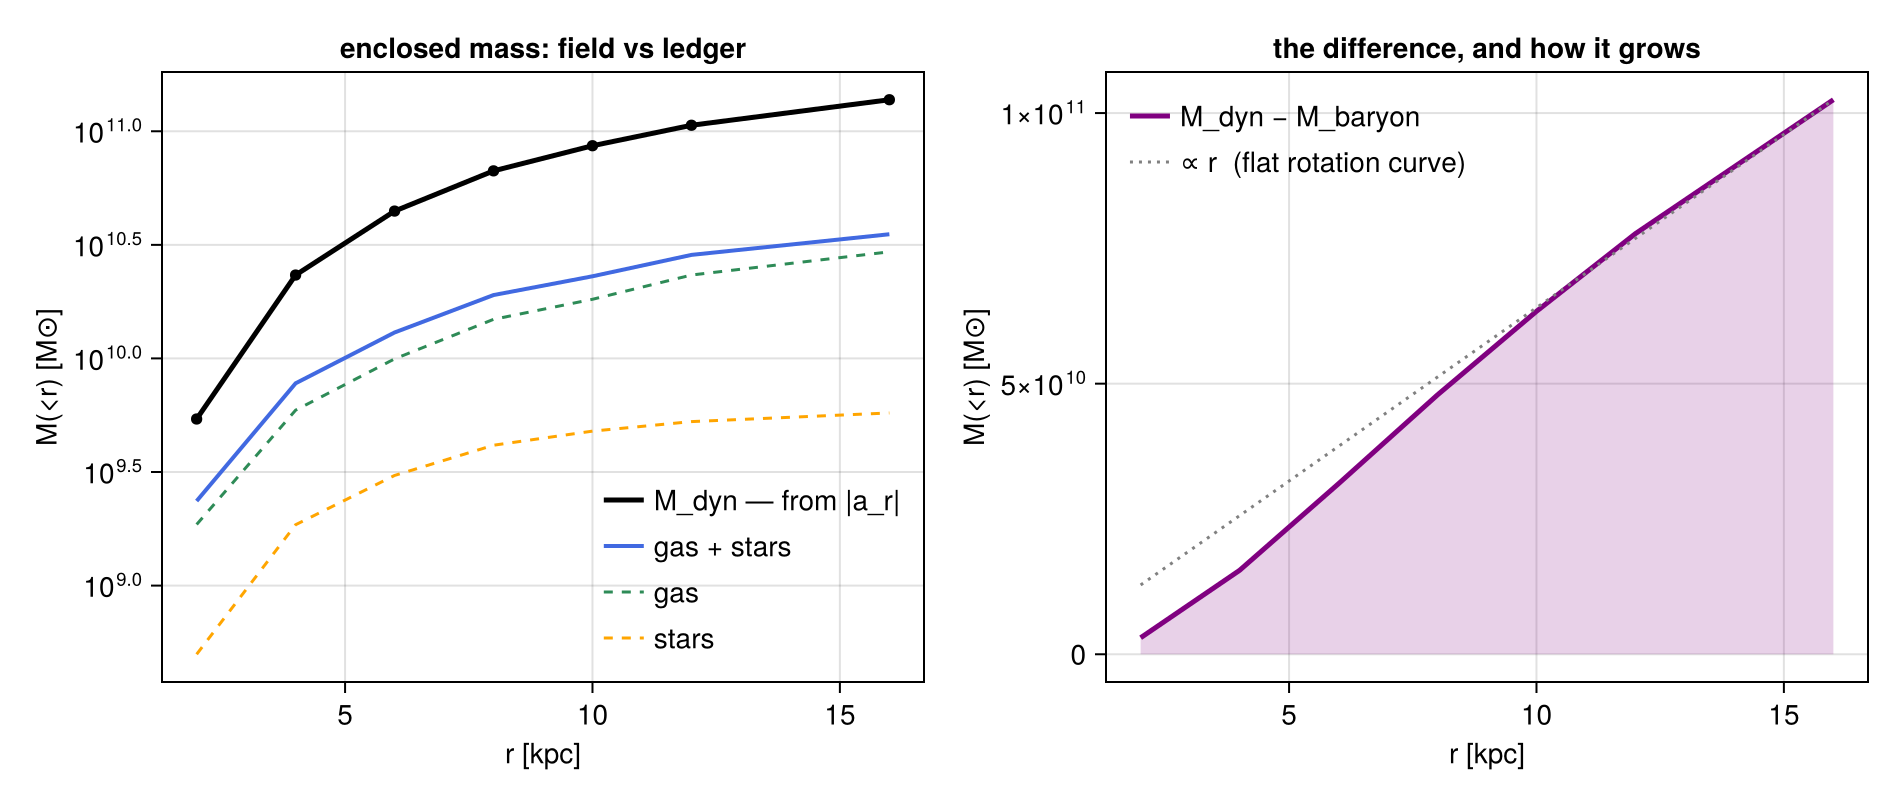

In [9]:
rr    = [t.r for t in rows]
Mdyn  = [t.Mdyn for t in rows]
Mbary = [t.Mgas + t.Mstar for t in rows]


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(950, 400))
ax1 = Axis(fig[1, 1], xlabel="r [kpc]", ylabel="M(<r) [M⊙]", yscale=log10,
           title="enclosed mass: field vs ledger")
lines!(ax1, rr, Mdyn; color=:black, linewidth=2.5, label="M_dyn — from |a_r|")
scatter!(ax1, rr, Mdyn; color=:black, markersize=8)
lines!(ax1, rr, Mbary; color=:royalblue, linewidth=2, label="gas + stars")
lines!(ax1, rr, [t.Mgas for t in rows]; color=:seagreen, linewidth=1.5, linestyle=:dash, label="gas")
lines!(ax1, rr, [t.Mstar for t in rows]; color=:orange, linewidth=1.5, linestyle=:dash, label="stars")
axislegend(ax1; position=:rb, framevisible=false)

ax2 = Axis(fig[1, 2], xlabel="r [kpc]", ylabel="M(<r) [M⊙]",
           title="the difference, and how it grows")
band!(ax2, rr, zeros(length(rr)), Mdyn .- Mbary; color=(:purple, 0.18))
lines!(ax2, rr, Mdyn .- Mbary; color=:purple, linewidth=2.5, label="M_dyn − M_baryon")
lines!(ax2, rr, (Mdyn[end]-Mbary[end]) .* rr ./ rr[end]; color=:grey, linewidth=1.5,
       linestyle=:dot, label="∝ r  (flat rotation curve)")
axislegend(ax2; position=:lt, framevisible=false)
fig


The field consistently reports more mass than the gas and stars in the same
sphere contain — a factor 2.3 at 2 kpc, rising to nearly 4 by 16 kpc. Over
the outer half of that range the gap grows very nearly linearly with radius,
which is the signature of a halo whose rotation curve is flat.

And the shortfall is not something the region selection dropped. The *entire*
particle population of this output — every particle in the box, not just those
inside the sphere — weighs $5.8 \times 10^9\,M_\odot$, more than an order of
magnitude less than the gap at 16 kpc. Whatever the field is responding to is
not represented in this output as cells or as particles at all.
That is a completely ordinary situation for an isolated-galaxy run, and it is
exactly the kind of thing a mass budget should be able to *detect* rather than
quietly absorb: the ledger of what you can see, the field of what is actually
pulling, and a region language that lets you ask both the same question.


## 7. A Second Opinion: the Gas Rotation

One more cross-check, and one more region shape. If $v_\mathrm{c}$ from §5 is
right, the gas — which sits in the midplane and moves in this potential —
should be going round at about that speed. `CylindricalShell(r_in, r_out, H)`
is the natural region for that: a thin annulus of the disc, half-height $H$.

Note that the two estimators share nothing except the geometry. One is a
volume-weighted mean of the gravitational acceleration; the other a
mass-weighted mean of the gas azimuthal velocity.


annulus at 7.5 kpc : v_φ(gas) = 190.3

 km/s   vs   v_c(field) = 189.1 km/s
outermost annulus  : 13942 cells — the gas disc has ended, the mean is meaningless


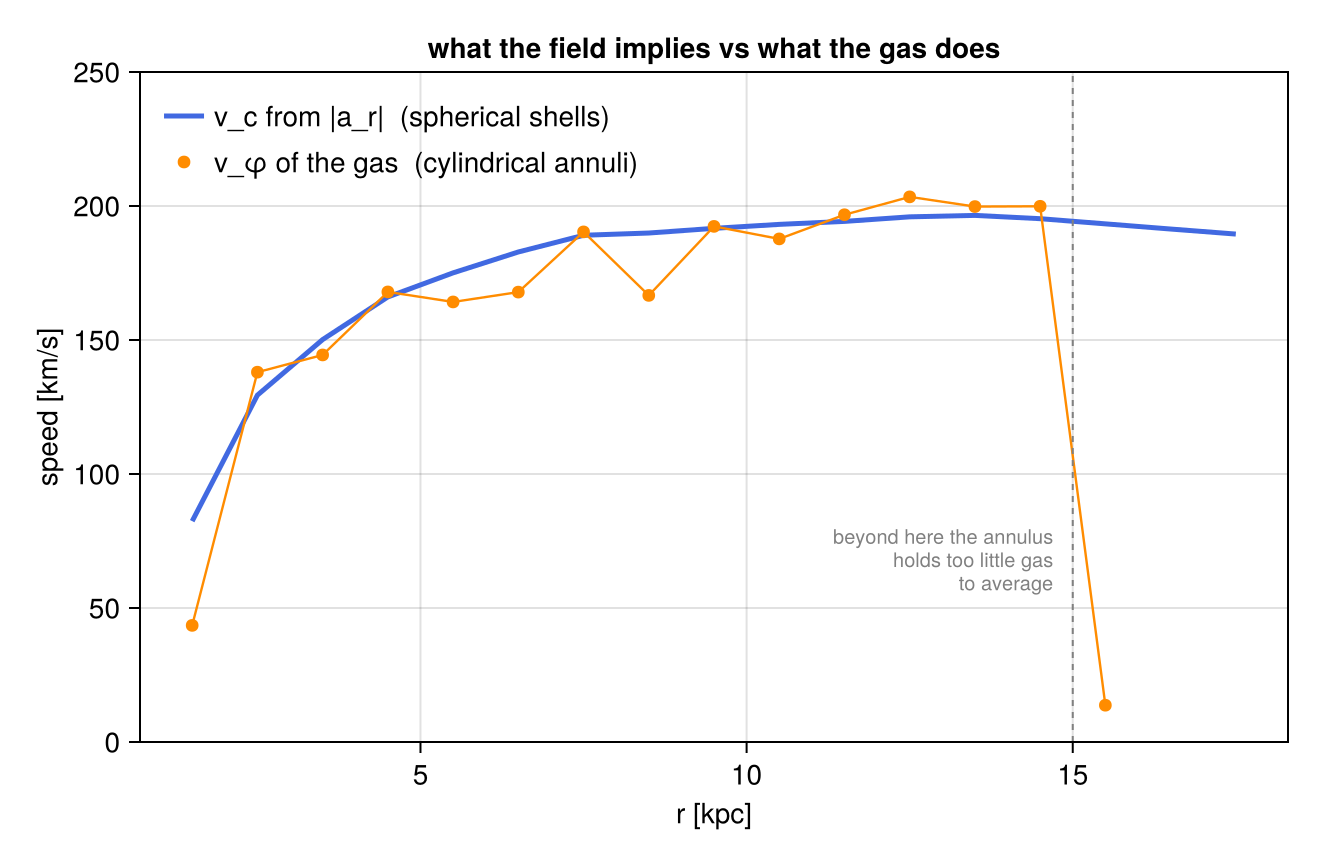

In [10]:
r_ann  = collect(1.5:1.0:15.5)
vphi   = Float64[]
ncells = Int[]
for r in r_ann
    an = subregion(gas, CylindricalShell(r - 0.5, r + 0.5, 0.5), verbose=false)
    m  = getvar(an, :mass, :Msol)                                  # fraction-aware
    v  = getvar(an, :vϕ_cylinder, :km_s, center=[:bc])             # ... and centred!
    push!(vphi, sum(v .* m) / sum(m))
    push!(ncells, length(an.data))
end
println("annulus at 7.5 kpc : v_φ(gas) = ", round(vphi[findfirst(==(7.5), r_ann)], digits=1),
        " km/s   vs   v_c(field) = ", round(vc_galaxy[findfirst(==(7.5), radii)], digits=1), " km/s")
println("outermost annulus  : ", ncells[end], " cells — the gas disc has ended, the mean is meaningless")


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(660, 430))
ax  = Axis(fig[1, 1], xlabel="r [kpc]", ylabel="speed [km/s]",
           title="what the field implies vs what the gas does")
lines!(ax, radii, vc_galaxy; color=:royalblue, linewidth=2.5, label="v_c from |a_r|  (spherical shells)")
scatter!(ax, r_ann, vphi; color=:darkorange, markersize=9, label="v_φ of the gas  (cylindrical annuli)")
lines!(ax, r_ann, vphi; color=:darkorange, linewidth=1.2)
vlines!(ax, [15.0]; color=:grey, linestyle=:dash, linewidth=1)
text!(ax, 14.7, 55; text="beyond here the annulus\nholds too little gas\nto average",
      color=:grey, fontsize=10, align=(:right, :bottom))
axislegend(ax; position=:lt, framevisible=false)
ylims!(ax, 0, 250)
fig


Out to the edge of the gas disc the two curves track each other within about
ten percent, and at 7.5 kpc they agree to better than one — good enough to
trust the units, the centres, and the sign conventions on both sides, which is
what a cross-check is for. The remaining scatter is physical:
the gas is not on perfectly circular orbits, it has pressure support and
non-axisymmetric structure, and a mass-weighted mean over a thick annulus is
not the same average as a volume-weighted one over a spherical shell.

Then the outermost orange point collapses — not because the rotation stops,
but because the annulus has run past the edge of the gas disc and there is
almost nothing left to average. The blue curve, which measures the field
rather than the material, carries straight on. Any profile built from regions
should report its cell counts alongside its values; that last point is a
number a region produced faithfully and a galaxy never had.


## 8. Composites, and the `@region` Block

The boolean algebra of the hydro page — `∩` `∪` `\` `!`, or their ASCII forms
`intersect`, `union`, `setdiff` — works unchanged on gravity data, and so does
the `@region` block that lets a composite be written once with the shared
keywords hoisted out.

Here: the disc slab with its nucleus removed, so the volume-weighted mean is
about the disc *outside* the core rather than dominated by it.


In [11]:
ring = @region unit=:kpc center=[:bc] begin
    disc = Cylinder(12, 2)      # radius 12 kpc, half-height 2 kpc
    core = Sphere(3)
    disc \ core                 # set difference: the slab minus the nucleus
end

g_ring = subregion(grav, ring, verbose=false)

# the same thing written with explicit constructors and operators
ring_ops = setdiff(Cylinder(12., 2.; center=[:bc], range_unit=:kpc),
                   Sphere(3.;        center=[:bc], range_unit=:kpc))
g_ops = subregion(grav, ring_ops, verbose=false)

V_ring = sum(getvar(g_ring, :volume, :kpc3))

# The nucleus is a sphere of radius 3 kpc but the slab is only ±2 kpc thick, so
# the difference removes just the sphere's middle band, ∫₋₂⁺² π(3² − z²) dz:
V_slab = π * 12^2 * 4                         # radius² × full height
V_band = π * (2*9*2 - 2*2^3/3)
println("ring volume            : ", round(V_ring, sigdigits=7), " kpc³")
println("analytic slab − band   : ", round(V_slab - V_band, sigdigits=7), " kpc³   dev = ",
        round(100*(V_ring/(V_slab - V_band) - 1), sigdigits=3), " %")
println("identical to the operator form : ",
        V_ring == sum(getvar(g_ops, :volume, :kpc3)))

wr = getvar(g_ring, :volume)
println("⟨epot⟩ over the ring   : ",
        round(sum(getvar(g_ring, :epot, :km2_s2) .* wr)/sum(wr), sigdigits=6), " (km/s)²")


ring volume            : 1712.947

 kpc³
analytic slab − band   : 1713.215 kpc³   dev = -0.0157 %
identical to the operator form : true


⟨epot⟩ over the ring   : 

-1600.32 (km/s)²


`@region` is only shorthand: it walks the block and injects `range_unit` and
`center` into every region constructor that does not already set them, then
returns an ordinary region value. Explicit keywords always win, and the result
is bit-identical to the operator form — as the check above confirms. The
[hydro page](03_hydro_Get_Subregions.md) covers the algebra itself in detail.

The analytic check is worth reading closely, because it is the kind of thing
set operations get right and intuition gets wrong. The nucleus is a sphere of
radius 3 kpc; the slab is only ±2 kpc thick. The sphere therefore pokes out
above and below, and `disc \ core` removes **only the part they share** — not
the whole sphere's volume. The measured region agrees with the corresponding
integral to a hundredth of a percent, which is a stronger statement than it
looks: it says the fractions on the cylinder's curved wall, on the sphere's
curved cap, and on the flat slab faces are all consistent with one another.


## 9. The Cut You Measure Is the Cut You See

The two-object projection accepts sub-region objects, so a field map can be
clipped by exactly the region the numbers came from. Because the gas object
carries the `:fraction` column, boundary pixels are weighted by how much of
each cell is really inside — the rim of the map feathers over one cell rather
than stepping along the grid.


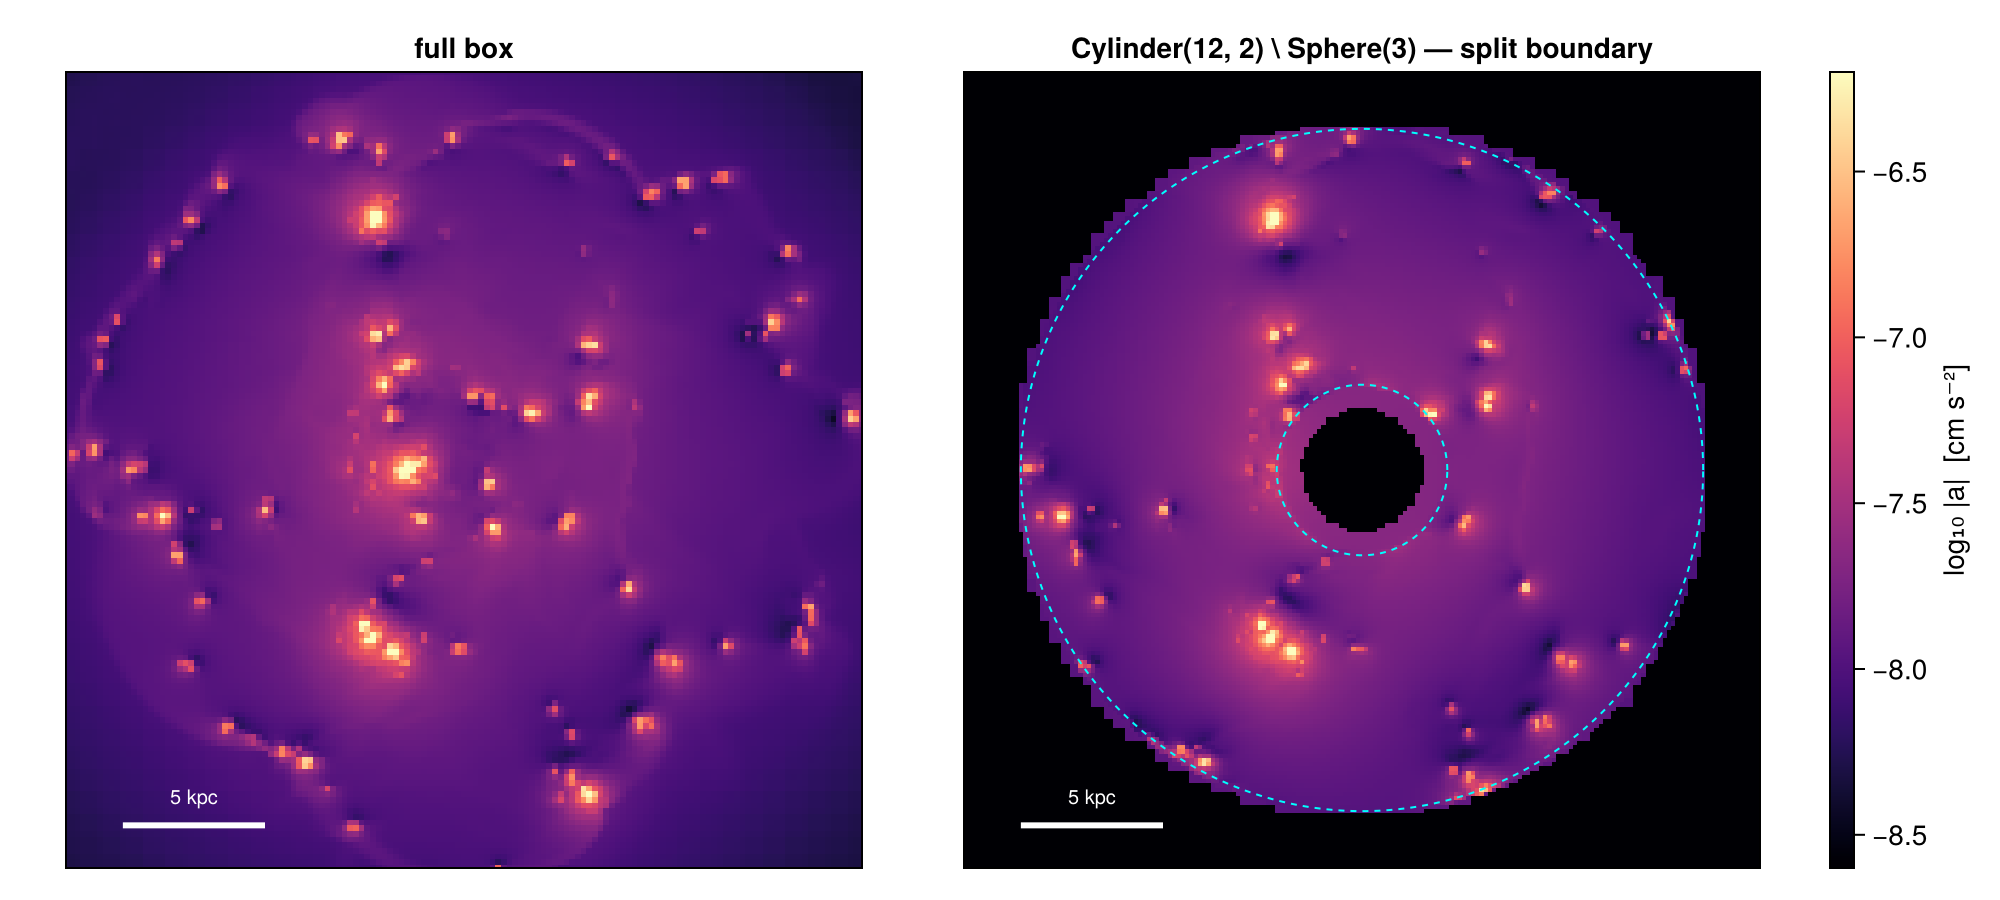

In [12]:
gas_ring  = subregion(gas,  ring, verbose=false)     # same region, both datasets
grav_ring = subregion(grav, ring, verbose=false)

p_ring = projection(gas_ring, grav_ring, :a_magnitude, :cm_s2; direction=:z,
                    center=[:bc], pxsize=[0.15, :kpc], xrange=[-14, 14], yrange=[-14, 14],
                    verbose=false, show_progress=false)


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1000, 450))
ax1 = Axis(fig[1, 1], title="full box", xlabel="x − x꜀ [kpc]", ylabel="y − y꜀ [kpc]")
show_a!(ax1, pa_face)
limits!(ax1, -14, 14, -14, 14)
scalebar!(ax1, -12, -12.5, 5)

ax2 = Axis(fig[1, 2], title="Cylinder(12, 2) \\ Sphere(3) — split boundary",
           xlabel="x − x꜀ [kpc]")
show_a!(ax2, p_ring)
limits!(ax2, -14, 14, -14, 14)
arc!(ax2, Point2f(0, 0), 12., 0, 2π; color=:cyan, linewidth=1, linestyle=:dash)
arc!(ax2, Point2f(0, 0),  3., 0, 2π; color=:cyan, linewidth=1, linestyle=:dash)
scalebar!(ax2, -12, -12.5, 5)
a_bar!(fig[1, 3])
fig


The hole is round, not staircased, and the outer rim ends where the cylinder
does. For a figure at a chosen pixel size, `refine_to=[0.15, :kpc]` on the
`subregion` call would push the feathering below the pixel scale — see §7 of
the hydro page for what that costs and when it is worth it.


## 10. Reference: the Classic Symbol API

The original symbol-based interface works on gravity data unchanged, and
remains the quickest way to take a rough cut. It is whole-cell by default
(`cell=true`), centre-test with `cell=false`, and it has no fraction column —
so `getvar(:volume)` after a classic cut counts whole cells, always.

| Value type | Classic call |
|:--|:--|
| `Cuboid(xrange=…, yrange=…, zrange=…)` | `subregion(grav, :cuboid; xrange=…, …)` |
| `Sphere(R)` | `subregion(grav, :sphere; radius=R)` |
| `Cylinder(R, H)` | `subregion(grav, :cylinder; radius=R, height=H)` (z-axis only) |
| `SphericalShell(rin, rout)` | `shellregion(grav, :sphere; radius=[rin, rout])` |
| `CylindricalShell(rin, rout, H)` | `shellregion(grav, :cylinder; radius=[rin, rout], height=H)` |

Shared keywords: `center`, `range_unit`, `inverse=true` for the complement,
`cell=true/false` for the boundary test.


In [13]:
cub_c = subregion(grav, :cuboid; xrange=[-12, 12], yrange=[-12, 12], zrange=[-2, 2],
                  center=[:bc], range_unit=:kpc, verbose=false)
shl_c = shellregion(grav, :sphere; radius=[10., 20.], center=[:bc], range_unit=:kpc,
                    verbose=false)

println("classic cuboid  : ", length(cub_c.data), " cells, V = ",
        round(sum(getvar(cub_c, :volume, :kpc3)), sigdigits=6), " kpc³ (whole cells)")
println("classic shell   : ", length(shl_c.data), " cells")
V_slab_split = sum(getvar(subregion(grav, Cuboid(xrange=[-12, 12], yrange=[-12, 12],
                                                 zrange=[-2, 2]), verbose=false),
                          :volume, :kpc3))
println()
println("value-type slab : ", round(V_slab_split, sigdigits=10), " kpc³ (split)")
println("analytic 24×24×4: ", 24*24*4, " kpc³   dev = ", V_slab_split/2304 - 1)


classic cuboid  : 3825112

 cells, V = 2457.87 kpc³ (whole cells)
classic shell   : 2197457 cells

value-type slab : 

2304.0 kpc³ (split)
analytic 24×24×4: 2304 kpc³   dev = 3.887778987632373e-12


The axis-aligned `Cuboid` is the one shape whose fractions are computed
analytically rather than sampled — a per-axis overlap product — so its split
volume matches the exact slab to machine precision, while the whole-cell
version carries a rim of boundary cells it never asked for.


## 11. Practical Guidance

**Weight by volume.** For gravity data there is no `msum`, and the mean over
cells is not the mean over the region. `getvar(obj, :volume)` is the weight you
want, and it is fraction-aware on a split region.

**Pass `center` twice.** Once to the region, to place it; once to `getvar`, for
any quantity whose name contains a geometry. They are different arguments with
different defaults, and getting the second one wrong produces a plausible
number rather than an error (§4) — Mera will remind you once per quantity, but
the reminder cannot know which origin you *meant*.

**Split when the boundary is the signal.** For a big sphere the fractions moved
the mean potential by parts in $10^5$ (§3); for a thin shell, a narrow slab, or
a region a few cells across, they are the whole story. When in doubt, measure
both — it is one extra line.

**Let the region be what the datasets share.** Gravity, hydro, and particles
are separate objects with separate columns, but one `Sphere(r)` value applies
to all three. That is what made §6 a comparison rather than an apples-to-oranges
table.

**Resolution.** The potential is smooth; `lmax` well below `levelmax` is
usually plenty for field work and costs far less memory than the hydro side
needs. Load the gravity data at the resolution your *question* has, not the one
the simulation was run at.


## Summary

- Gravity cells carry a field, not mass: `msum` and `getvar(:mass)` do not
  apply, and a region's payload is its **volume**. Everything else about
  regions — value types, `:fraction` splitting, `∩ ∪ \ !`, `@region`, tilted
  axes, `inverse` — behaves exactly as on the hydro side.
- Split volumes match analytic volumes to the sub-sampling limit; whole-cell
  cuts over-count and centre tests have no guaranteed sign (§2).
- Average fields **by volume**, never by cell count (§3), and give `getvar` the
  same `center` you gave the region (§4) — both mistakes return numbers rather
  than errors, though the second one now announces itself once per quantity.
- Shells of regions make radial profiles: the volume-weighted $a_r$ gives a
  rotation curve that flattens near 190 km/s (§5) and, through Gauss's law, an
  enclosed mass three to four times the gas and stars found in the same
  spheres (§6) — a dark component the output never wrote down, detected by
  asking one region two independent questions.
- The gas's own rotation agrees with the field to about ten percent inside the
  disc (§7), which is how you know the centres and units were right.

**Continue with:**

- [Hydro sub-regions](03_hydro_Get_Subregions.md) — the full treatment of
  region algebra, exact splitting, and mass budgets.
- The sibling pages for [particles](03_particles_Get_Subregions.md) and
  [clumps](03_clumps_Get_Subregions.md).
- [Masking & Filtering](05_multi_Masking_Filtering.md) — select by *value*
  instead of by place, and combine the two.
